In [ ]:


from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


DATA PREPROCESSING

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
import multiprocessing

# Define paths
ORIGINAL_IMAGES_PATH = '/content/drive/MyDrive/ROCO/data/train/radiology/images'
OUTPUT_DIR = '/content/drive/MyDrive/ROCO/data/preprocessed_images'

def preprocess_single_image(args):
    """Preprocess a single image"""
    image_path, output_dir, size = args
    try:
        # Generate output filename
        filename = os.path.basename(image_path)
        output_path = os.path.join(output_dir, filename)

        # Skip if already processed
        if os.path.exists(output_path):
            return None

        # Process image
        img = Image.open(image_path).resize((size, size)).convert('RGB')
        img_array = np.array(img) / 255.0

        # Save processed image as numpy array
        np.save(output_path.replace('.jpg', '.npy').replace('.png', '.npy'), img_array)
        return output_path
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None

def create_dataset(image_files, output_dir, size=128, batch_size=1000, test_size=0.2):
    """Process images in batches and create train/test splits"""
    # Create output directories
    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    print(f"Created output directories at:\n{train_dir}\n{test_dir}")

    # Split into train and test sets
    train_files, test_files = train_test_split(image_files, test_size=test_size, random_state=42)

    # Process training and test sets separately
    for split_name, split_files, split_dir in [('Training', train_files, train_dir),
                                             ('Testing', test_files, test_dir)]:
        print(f"\nProcessing {split_name} Set:")

        # Process in batches
        for i in range(0, len(split_files), batch_size):
            batch_files = split_files[i:i + batch_size]

            # Prepare arguments for parallel processing
            args = [(f, split_dir, size) for f in batch_files]

            # Use ThreadPoolExecutor for parallel processing
            with ThreadPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
                list(tqdm(executor.map(preprocess_single_image, args),
                         total=len(batch_files),
                         desc=f"Batch {i//batch_size + 1}"))

def load_processed_dataset(preprocessed_dir):
    """Load preprocessed images from directory"""
    train_dir = os.path.join(preprocessed_dir, 'train')
    test_dir = os.path.join(preprocessed_dir, 'test')

    def load_from_dir(directory):
        files = [f for f in os.listdir(directory) if f.endswith('.npy')]
        data = []
        for f in tqdm(files, desc=f"Loading {os.path.basename(directory)} data"):
            data.append(np.load(os.path.join(directory, f)))
        return np.array(data)

    train_data = load_from_dir(train_dir)
    test_data = load_from_dir(test_dir)

    return train_data, test_data

if __name__ == "__main__":
    # Verify paths exist
    if not os.path.exists(ORIGINAL_IMAGES_PATH):
        raise ValueError(f"Original images path not found: {ORIGINAL_IMAGES_PATH}")

    # Create output directory if it doesn't exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Get list of image files
    print("Finding image files...")
    image_files = [os.path.join(ORIGINAL_IMAGES_PATH, f) for f in os.listdir(ORIGINAL_IMAGES_PATH)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    print(f"Found {len(image_files)} images to process")

    # Process images
    create_dataset(
        image_files=image_files,
        output_dir=OUTPUT_DIR,
        size=128,
        batch_size=1000,
        test_size=0.2
    )

    print("\nProcessing complete!")
    print(f"Preprocessed images are saved in: {OUTPUT_DIR}")

    # Optional: Load and verify the processed dataset
    print("\nLoading processed dataset to verify...")
    train_data, test_data = load_processed_dataset(OUTPUT_DIR)
    print(f"Training data shape: {train_data.shape}")
    print(f"Testing data shape: {test_data.shape}")

Finding image files...
Found 48079 images to process
Created output directories at:
/content/drive/MyDrive/ROCO/data/preprocessed_images/train
/content/drive/MyDrive/ROCO/data/preprocessed_images/test

Processing Training Set:


Batch 39: 100%|██████████| 463/463 [00:12<00:00, 37.73it/s]



Processing Testing Set:


Batch 10: 100%|██████████| 616/616 [00:19<00:00, 31.37it/s]



Processing complete!
Preprocessed images are saved in: /content/drive/MyDrive/ROCO/data/preprocessed_images

Loading processed dataset to verify...


Loading train data:  71%|███████   | 27135/38463 [24:45<2:28:09,  1.27it/s]

DISPLAYING A SAMPLE OF PREPROCESSED IMAGE

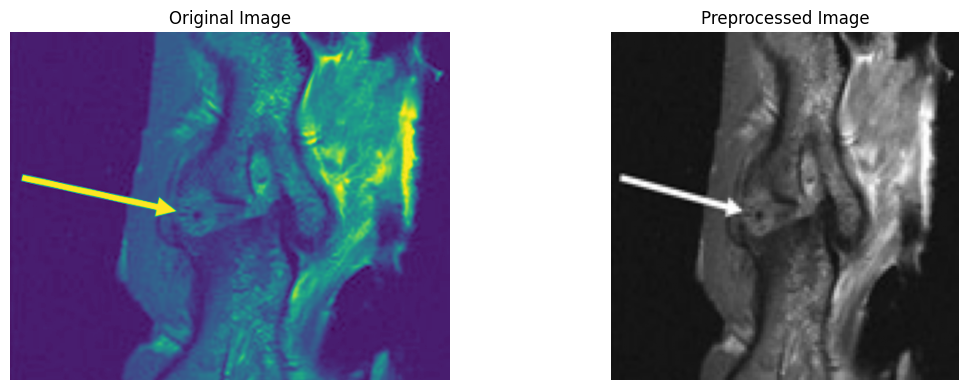


File: ROCO_49477.npy
Shape: (128, 128, 3)
Value Range: [0.035, 1.000]


In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

def fast_visualize_sample(original_path, preprocessed_dir, sample_size=1):
    """
    Quickly display a random sample from preprocessed dataset.

    Args:
        original_path: Path to original images
        preprocessed_dir: Path to preprocessed numpy arrays
        sample_size: Number of random samples to select (default=1)
    """
    # Get train directory path
    train_dir = os.path.join(preprocessed_dir, 'train')

    # Get list of preprocessed files efficiently
    preprocessed_files = os.listdir(train_dir)
    npy_files = [f for f in preprocessed_files if f.endswith('.npy')]

    if not npy_files:
        print("No preprocessed files found!")
        return

    # Randomly select files without loading all files into memory
    selected_files = random.sample(npy_files, min(sample_size, len(npy_files)))


    for sample_file in selected_files:
        # Load preprocessed image
        preprocessed_path = os.path.join(train_dir, sample_file)
        preprocessed_array = np.load(preprocessed_path)

        # Find corresponding original image
        original_filename = sample_file.replace('.npy', '')
        original_file = None

        # Check for both jpg and png extensions
        for ext in ['.jpg', '.jpeg', '.png']:
            temp_path = os.path.join(original_path, original_filename + ext)
            if os.path.exists(temp_path):
                original_file = temp_path
                break

        if original_file is None:
            print(f"Original image not found for {sample_file}")
            continue

        # Load and display images
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Display original image
        original_img = Image.open(original_file)
        ax1.imshow(original_img)
        ax1.set_title('Original Image')
        ax1.axis('off')

        # Display preprocessed image
        ax2.imshow(preprocessed_array)
        ax2.set_title('Preprocessed Image')
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

        # Print basic array information (only essential info)
        print(f"\nFile: {sample_file}")
        print(f"Shape: {preprocessed_array.shape}")
        print(f"Value Range: [{preprocessed_array.min():.3f}, {preprocessed_array.max():.3f}]")


if __name__ == "__main__":
    ORIGINAL_IMAGES_PATH = '/content/drive/MyDrive/ROCO/data/train/radiology/images'
    OUTPUT_DIR = '/content/drive/MyDrive/ROCO/data/preprocessed_images'

    # Visualize one random sample
    fast_visualize_sample(ORIGINAL_IMAGES_PATH, OUTPUT_DIR)